# Find SAM2 Parameters

In [2]:
import os
# if using Apple MPS, fall back to CPU for unsupported ops
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import natsort

In [3]:
np.random.seed(3)

def show_anns(anns, borders=True):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:, :, 3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.5]])
        img[m] = color_mask 
        if borders:
            import cv2
            contours, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 
            # Try to smooth contours
            contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
            cv2.drawContours(img, contours, -1, (0, 0, 1, 0.4), thickness=1) 

    ax.imshow(img)

(3648, 5472, 3)


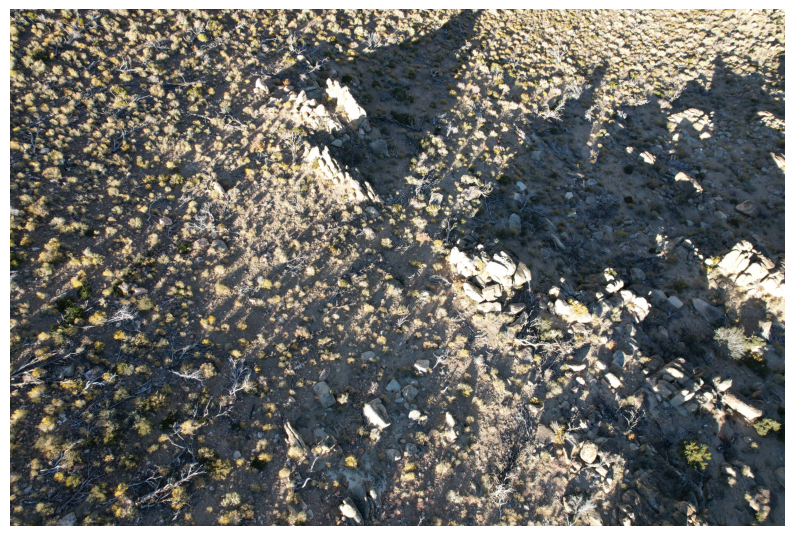

In [4]:
image = Image.open('../data/centennial_bluff/mission_a/DJI_photos/DJI_0001.JPG')
image = np.array(image.convert("RGB"))

print(image.shape)

plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis('off')
plt.show()

In [5]:
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

sam2_checkpoint = "../semantic_SfM/sam2/sam2.1_hiera_large.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"

# device = torch.device("cuda")
device = torch.device("cuda:3")

sam2 = build_sam2(model_cfg, sam2_checkpoint, device=device, apply_postprocessing=False)

/home/zchen256/sam2/sam2/modeling/sam/transformer.py:23: UserWarning: Flash Attention is disabled as it requires a GPU with Ampere (8.0) CUDA capability.
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()


In [6]:
mask_generator_2 = SAM2AutomaticMaskGenerator(
    model=sam2,
    points_per_side=128,
    points_per_batch=128,
    #pred_iou_thresh=0.6,
    #stability_score_thresh=0.96,
    #stability_score_offset=0.5,
    #mask_threshold = 0.0,
    crop_n_layers=3,
    #box_nms_thresh=0.6,
    #crop_n_points_downscale_factor=1,
    #min_mask_region_area=100000.0,
    #use_m2m=True,
    #multimask_output=True,
)

In [7]:
scale_factor = 0.5
image_resized = cv2.resize(image, (0, 0), fx=scale_factor, fy=scale_factor)
print(image_resized.shape)

(1824, 2736, 3)


In [8]:
masks = mask_generator_2.generate(image_resized)

print(len(masks))

4185


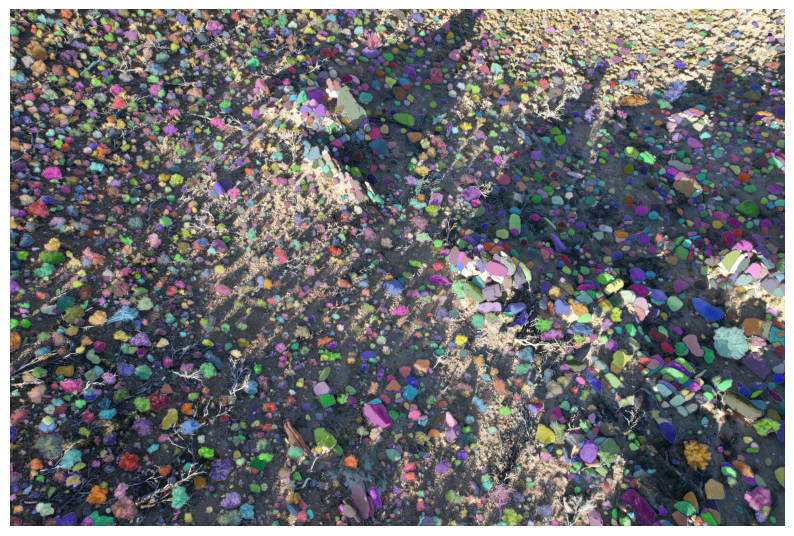

In [9]:
plt.figure(figsize=(10, 10))
plt.imshow(image_resized)
show_anns(masks)
plt.axis('off')
plt.show() 

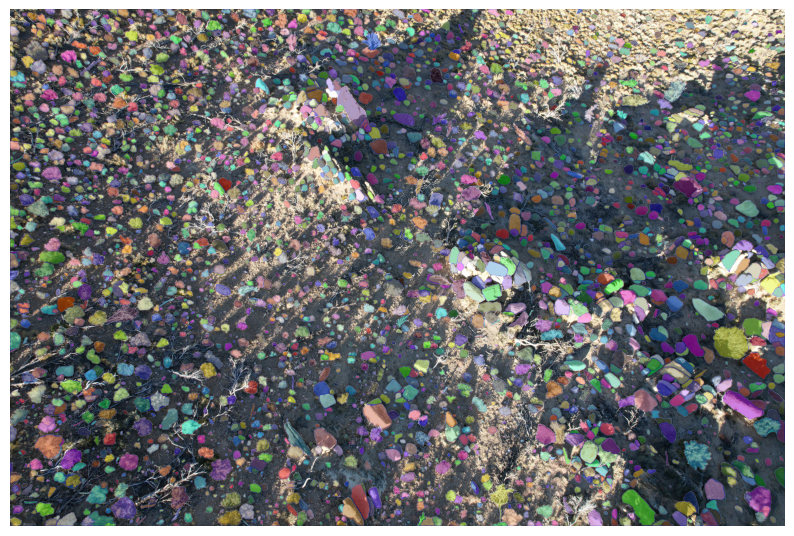

In [16]:
plt.figure(figsize=(10, 10))
plt.imshow(image_resized)
show_anns(masks)
plt.axis('off')
plt.show() 

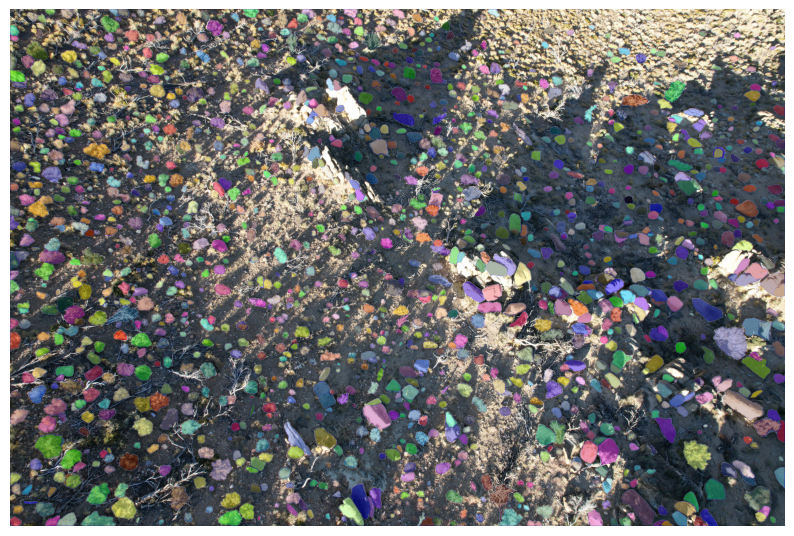

In [12]:
plt.figure(figsize=(10, 10))
plt.imshow(image_resized)
show_anns(masks)
plt.axis('off')
plt.show() 

# SAM2 Segmentation

In [71]:
from ssfm.image_segmentation import ImageSegmentation
from ssfm.image_segmentation import ParallelImageSegmentation
import os

In [72]:
photos_folder_path = '../data/centennial_bluff/mission_b/DJI_photos/'
segmentations_folder_path = '../data/centennial_bluff/mission_b/segmentations/'
camera_path = '../data/centennial_bluff/mission_b/SfM_products/b.xml'


# photos_folder_path = '../data/centennial_bluff/mission_a/DJI_photos/'
# segmentations_folder_path = '../data/centennial_bluff/mission_a/segmentations/'
# camera_path = '../data/centennial_bluff/mission_a/SfM_products/a.xml'

In [7]:
image_path_list = [os.path.join(photos_folder_path, image) for image in os.listdir(photos_folder_path)]

# sort images based on the values of keyimages in file names
image_path_list = sorted(image_path_list, key=lambda x: int(x.split('/')[-1].split('.')[0].split('_')[-1]))

image_list = [image for image in os.listdir(photos_folder_path)]

# sort images based on the values of keyimages in file names
image_list = sorted(image_list, key=lambda x: int(x.split('/')[-1].split('.')[0].split('_')[-1]))

# print the length of the image list
print(len(image_list))

801


In [ ]:
sam_params = {}
sam_params['model_name'] = 'sam2'
sam_params['model_path'] = '../semantic_SfM/sam2/sam2.1_hiera_large.pt'
sam_params['model_type'] = None
sam_params['devices'] = ['cuda:3', 'cuda:4', 'cuda:5', 'cuda:6', 'cuda:7']
sam_params['points_per_side'] = 128
sam_params['points_per_batch'] = 128
sam_params['pred_iou_thresh'] = 0.8  # SAM2 default
sam_params['stability_score_thresh'] = 0.95  # SAM2 default
sam_params['stability_score_offset'] = 0.5  # SAM2 default
sam_params['box_nms_thresh'] = 0.7 # SAM2 default
sam_params['use_m2m'] = False
sam_params['crop_n_layers'] = 2

parallel_image_segmentation = ParallelImageSegmentation(sam_params)
parallel_image_segmentation.parallel_predict(image_paths=image_path_list, segmentation_folder_path=segmentations_folder_path, maximum_size=2500, save_overlap=True, skip_existing=True, camera_parameters_path=camera_path)

# Post-process SAM2 segmentations

1. Simple mask filter

Find out moving average windows size

In [75]:
segmentations_folder_path = '../data/centennial_bluff/mission_a/segmentations/'
associations_folder_path = '../data/centennial_bluff/mission_a/associations/'
segmentation_list = [segmentation for segmentation in os.listdir(segmentations_folder_path) if segmentation.endswith('.npy')]
segmentation_list = natsort.natsorted(segmentation_list)
segmentation_file_path = os.path.join(segmentations_folder_path, segmentation_list[4])
masks = np.load(segmentation_file_path)
print("Segmentation file path: ", segmentation_file_path)
print("Number of masks: ", np.max(masks) + 1)

Segmentation file path:  ../data/centennial_bluff/mission_a/segmentations/DJI_0005.npy
Number of masks:  5844


In [38]:
mask_sizes = []
for i in range(np.max(masks)+1):
    mask_sizes.append(np.sum(masks == i))

mask_sizes = np.array(mask_sizes)

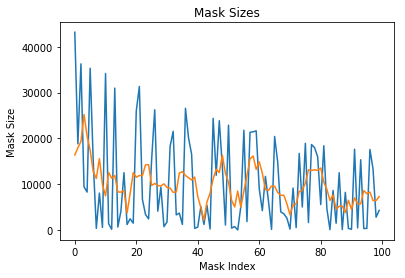

In [49]:
def moving_average(data, window_size):
    window = np.ones(int(window_size)) / float(window_size)
    return np.convolve(data, window, 'same')

mask_sizes_ma = moving_average(mask_sizes, 6)

index = 100
plt.plot(mask_sizes[:index])
plt.plot(mask_sizes_ma[:index])
plt.xlabel('Mask Index')
plt.ylabel('Mask Size')
plt.title('Mask Sizes')
plt.show()

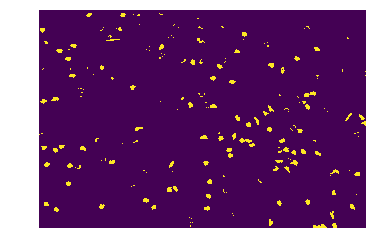

(3648, 5472)


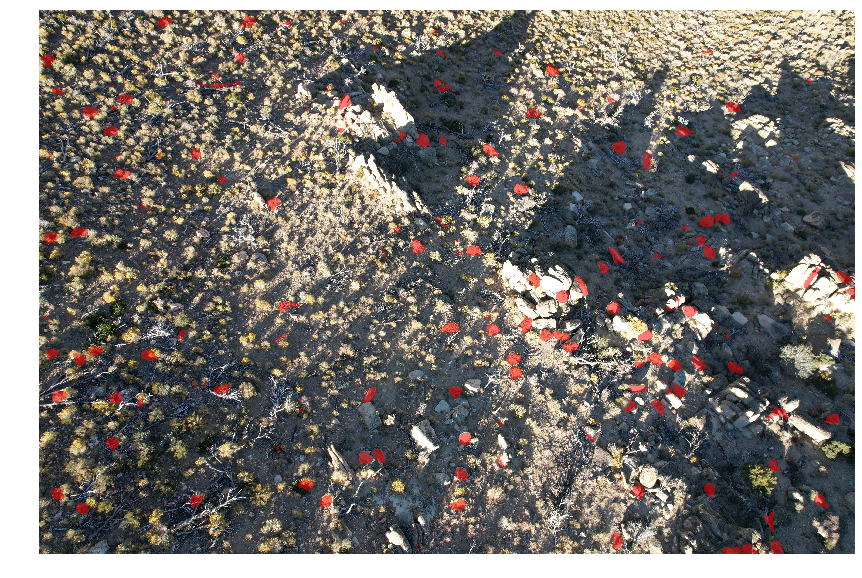

In [42]:
# plot a specific mask i
mask_index = 1000
mask = (800 < masks) & (masks < mask_index + 1)
plt.imshow(mask)
plt.axis('off')
plt.show()
print(mask.shape)

image_path = '../data/centennial_bluff/mission_a/DJI_photos/DJI_0001.JPG'
image = Image.open(image_path)
image = np.array(image.convert("RGB"))
# overlay the mask on the image using alpha blending
image_with_mask = image.copy()
image_with_mask[mask] = (image_with_mask[mask] * 0.5 + 0.5 * np.array([255, 0, 0])).astype(np.uint8)



# set figure size
plt.figure(figsize=(15, 10))
plt.imshow(image_with_mask)
plt.axis('off')
plt.show()


In [76]:
from ssfm.simple_mask_filter import SimpleMaskFilter

In [77]:
configs = {
    'window_size': 6,
    'depth_folder': os.path.join(associations_folder_path, 'depth'),
    'output_folder': "../data/centennial_bluff/mission_a/segmentations_filtered",
    'area_upper_threshold': 25,
    'area_lower_threshold': 0.01,
    'erosion_kernel_size': 5,
    'erosion_iteration':1,
    'camera_parameter_file': "../data/centennial_bluff/mission_a/SfM_products/a.xml",
    'background_mask': True,
    'skip_existing': False,
}

mask_filter = SimpleMaskFilter(configs)

mask_filter.filter_batch_processes(segmentations_folder_path, num_processes=32)

Total number of files: 801


100%|██████████| 801/801 [8:04:11<00:00, 36.27s/it]  


verify the simple filtering results

In [63]:
segmentations_folder_path = '../data/centennial_bluff/mission_a/segmentations_filtered/'
image_folder_path = '../data/centennial_bluff/mission_a/DJI_photos/'


segmentation_file_path = os.path.join(segmentations_folder_path, "DJI_0003.npy")
image_file_path = os.path.join(image_folder_path, "DJI_0003.JPG")
masks = np.load(segmentation_file_path)
print("Segmentation file path: ", segmentation_file_path)
print("Number of masks: ", np.max(masks) + 1)

Segmentation file path:  ../data/centennial_bluff/mission_a/segmentations_filtered/DJI_0003.npy
Number of masks:  1936


In [64]:
mask_sizes = []
for i in range(np.max(masks)+1):
    mask_sizes.append(np.sum(masks == i))

mask_sizes = np.array(mask_sizes)

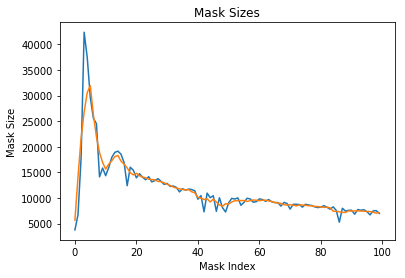

Number of masks:  1936


In [65]:
mask_sizes_ma = moving_average(mask_sizes, 5)

index = 100
plt.plot(mask_sizes[:index])
plt.plot(mask_sizes_ma[:index])
plt.xlabel('Mask Index')
plt.ylabel('Mask Size')
plt.title('Mask Sizes')
plt.show()
print("Number of masks: ", np.max(masks) + 1)

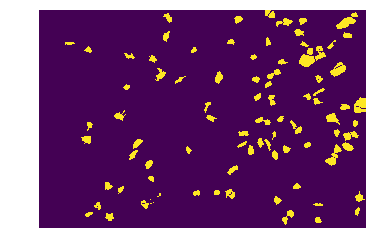

(3648, 5472)


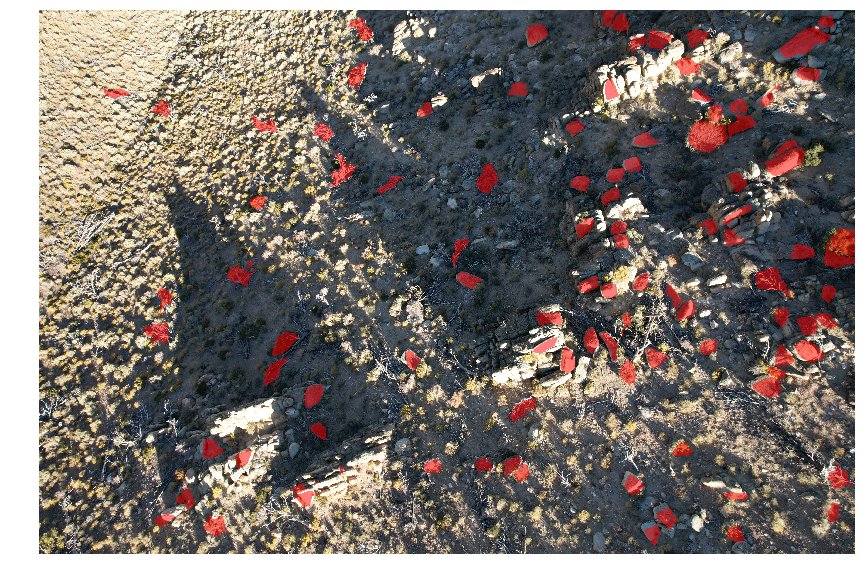

In [70]:
mask_index = 100
mask = (0 < masks) & (masks < mask_index + 1)
#mask = masks == mask_index
plt.imshow(mask)
plt.axis('off')
plt.show()
print(mask.shape)

image_path = '../data/centennial_bluff/mission_a/DJI_photos/DJI_0003.JPG'
image = Image.open(image_path)
image = np.array(image.convert("RGB"))
# overlay the mask on the image using alpha blending
image_with_mask = image.copy()
image_with_mask[mask] = (image_with_mask[mask] * 0.5 + 0.5 * np.array([255, 0, 0])).astype(np.uint8)



# set figure size
plt.figure(figsize=(15, 10))
plt.imshow(image_with_mask)
plt.axis('off')
plt.show()

In [58]:
# keep the masks in mask_sizes that are above the mask_sizes_ma
mask_sizes = np.array(mask_sizes)
mask_sizes_ma = moving_average(mask_sizes, 6)
mask_sizes_ = mask_sizes[mask_sizes > mask_sizes_ma]


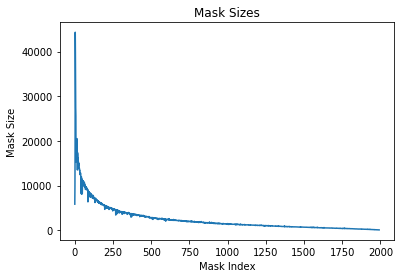

In [60]:
plt.plot(mask_sizes_[:-5])
plt.xlabel('Mask Index')
plt.ylabel('Mask Size')
plt.title('Mask Sizes')
plt.show()

In [78]:
configs = {
    'window_size': 6,
    'depth_folder': os.path.join(associations_folder_path, 'depth'),
    'output_folder': "../data/centennial_bluff/mission_a/segmentations_filtered",
    'area_upper_threshold': 25,
    'area_lower_threshold': 0.01,
    'erosion_kernel_size': 5,
    'erosion_iteration':1,
    'camera_parameter_file': "../data/centennial_bluff/mission_a/SfM_products/a.xml",
    'background_mask': True
}

mask_filter = SimpleMaskFilter(configs)

mask_filter.filter_batch_processes("../data/centennial_bluff/mission_a/segmentations_filtered", num_processes=16)

Total number of files: 801


100%|██████████| 801/801 [5:27:19<00:00, 24.52s/it]  
